In [51]:
import pandas as pd
from utils.data_processing import process_string

import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

In [52]:
plant_groups = {
    "Leafy Greens & Salad Vegetables": [
        "spinach",
        "lettuce",
        "arugula",
        "rucola",
        "kale",
        "chard",
        "endive",
        "cress",
        "garden cress",
        "watercress",
        "corn salad",
        "cornsalad",
        "nüsslisalat",
        "lamb's lettuce",
        "sorrel",
        "chicory",
        "batavia lettuce",
        "water spinach",
    ],
    "Cruciferous Vegetables": [
        "broccoli",
        "cauliflower",
        "cabbage",
        "brussels sprout",
        "chinese cabbage",
        "kohlrabi",
        "romanesco",
        "horseradish",
        "radish",
        "turnip",
        "mustard",
        "wasabi",
        "bimi",
    ],
    "Root Vegetables": [
        "carrot",
        "beetroot",
        "beet",
        "parsnip",
        "potato",
        "sweet potato",
        "jerusalem artichoke",
        "cassava",
        "salsify",
        "black salsify",
        "crosne",
        "konjac",
        "tapioca",
    ],
    "Allium Family": [
        "onion",
        "garlic",
        "leek",
        "shallot",
        "echalotte",
        "chives",
        "wild garlic",
    ],
    "Nightshades": [
        "tomato",
        "green tomato",
        "eggplant",
        "aubergine",
        "bell pepper",
        "chili",
        "chilli",
        "chili pepper",
        "jalapeno",
        "jalapeño",
        "padron pepper",
        "cayenne",
        "paprika",
    ],
    "Cucurbits": ["cucumber", "zucchini", "courgette", "squash", "pumpkin"],
    "Legumes": [
        "bean",
        "common bean",
        "green bean",
        "black bean",
        "kidney bean",
        "white bean",
        "borlotti bean",
        "adzuki bean",
        "adzukibohne",
        "flageolet",
        "mung bean",
        "mungbean",
        "pea",
        "peas",
        "chickpea",
        "lentil",
        "lens",
        "lupin",
        "fava bean",
        "soy",
        "soya",
        "soybean",
        "edamame",
        "alfalfa",
    ],
    "Grains & Pseudocereals": [
        "rice",
        "wheat",
        "oat",
        "spelt",
        "corn",
        "maize",
        "quinoa",
        "amaranth",
        "chia",
    ],
    "Herbs": [
        "basil",
        "tarragon",
        "chervil",
        "coriander",
        "oregano",
        "parsley",
        "mint",
        "peppermint",
        "rosemary",
        "sage",
        "thyme",
        "dill",
        "nettle",
    ],
    "Fruits Used as Vegetables": [
        "avocado",
        "olive",
        "tamarind",
        "mango",
        "apple",
        "fig",
        "cherry",
        "raspberry",
        "strawberry",
        "lemon",
    ],
    "Nuts & Seeds": [
        "almond",
        "sesame",
        "flax",
        "flaxseed",
        "linseed",
        "sunflower",
        "peanut",
        "pistachio",
        "cashew",
        "macadamia",
        "pine",
        "chestnut",
        "chestnuts",
        "coconut",
        "carob",
    ],
    "Stalks & Stems": [
        "celery",
        "celeri",
        "celeriac",
        "fennel",
        "asparagus",
        "rhubarb",
        "bamboo",
        "cardoon",
        "artichoke",
    ],
    "Seaweeds & Algae": ["algae", "seaweed", "wakame", "nori", "chlorella"],
    "Spices": [
        "vanilla",
        "cinnamon",
        "turmeric",
        "curcuma",
        "pepper",
        "ginger",
        "laurel",
        "caper",
        "capers",
    ],
    "Other Specialty Plants": [
        "hemp",
        "aloe vera",
        "eucalyptus",
        "elderflower",
        "guarana",
        "maca",
        "glasswort",
        "plantain",
        "cocoa",
        "palm",
    ],
}

In [53]:
meta = pd.read_csv(
    "../../data/fay_meta_diets.csv",
)

In [54]:
plant_group_annotations = pd.read_csv("../../data/plant_group_annotations.csv")

plant_group_annotations = plant_group_annotations[
    ~plant_group_annotations["food_group"].isin(["mixed", "other"])
]

In [55]:
plant_group_annotations["food_group"].unique()

array(['eggplant', 'beetroot', 'broccoli', 'carrot', 'celery', 'celeriac',
       'cabbage', 'brussels sprout', 'chinese cabbage', 'cauliflower',
       'kohlrabi', 'squash', 'zucchini', 'chicory', 'spinach', 'fennel',
       'soybean', 'common bean', 'green bean', 'lentil', 'corn', 'onion',
       'pea', 'leek', 'chickpea', 'bell pepper', 'black salsify',
       'tomato', 'cassava', 'sweet potato', 'jerusalem artichoke',
       'potato', 'algae', 'wild garlic', 'cress', 'arugula',
       "lamb's lettuce", 'artichoke', 'bean', 'cucumber', 'caper',
       'pumpkin', 'chili pepper', 'horseradish', 'parsnip', 'radish',
       'turnip', 'salsify', 'romanesco', 'garlic', 'shallot', 'cardoon',
       'chard', 'mungbean', 'asparagus', 'alfalfa', 'bamboo', 'lupin',
       'rhubarb', 'olive', 'coconut', 'rice', 'basil', 'chili',
       'tarragon', 'ginger', 'chervil', 'coriander', 'oregano', 'parsley',
       'pepper', 'peppermint', 'rosemary', 'sage', 'chives', 'thyme',
       'vanilla', 'cinn

In [56]:
# Create a mapping dictionary that maps each plant to its group
plant_to_group = {}
for group, plants in plant_groups.items():
    for plant in plants:
        plant_to_group[plant] = group


# Function to find the broad group for a food_group
def get_broad_group(food_group):
    # Clean input by converting to lowercase and stripping whitespace
    if not isinstance(food_group, str):
        return "Unknown"

    food_group = food_group.lower().strip()

    # Check if the exact food_group is in our mapping
    if food_group in plant_to_group:
        return plant_to_group[food_group]

    # If not found directly, try to find a partial match
    for plant in plant_to_group.keys():
        if plant in food_group or food_group in plant:
            return plant_to_group[plant]

    # If no match is found
    return "Unknown"


# Now add the broad_level_group column to your dataframe
plant_group_annotations["broad_level_group"] = plant_group_annotations[
    "food_group"
].apply(get_broad_group)

In [57]:
plant_group_annotations

,food_item,food_group,broad_level_group
0,"Eggplant, slices, breaded, prepared",eggplant,Nightshades
1,"Beetroot, steamed, without addition of salt",beetroot,Root Vegetables
2,"Broccoli, steamed, without addition of salt",broccoli,Cruciferous Vegetables
6,"Carrot, steamed, without addition of salt",carrot,Root Vegetables
7,"Celery, steamed, without addition of salt",celery,Stalks & Stems
...,...,...,...
4208,Giovanni Rana spinach gnocchi with spinach,spinach,Leafy Greens & Salad Vegetables
4214,Coop Bio Cauliflower Burger,cauliflower,Cruciferous Vegetables
4241,"Seapoint farms - Dry roasted Edamame, wasabi",edamame,Legumes
4243,Alnatura - Streichcreme (Aubergine),aubergine,Nightshades


In [58]:
# Individual food class
plant_dict = dict(
    zip(plant_group_annotations["food_item"], plant_group_annotations["food_group"])
)

# OR

# Broad-level food classes
# plant_dict = dict(
#     zip(
#         plant_group_annotations["food_item"],
#         plant_group_annotations["broad_level_group"],
#     )
# )

In [151]:
df_food = pd.read_csv(
    "../../data/df_food_trimmed.csv",
    index_col=0,
)

## get the date of the meal from "eaten_at" column
df_food["eaten_date"] = pd.to_datetime(df_food["eaten_at"]).dt.date

df_food["plant_group"] = df_food["combined_name"].map(plant_dict)

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_74865/1436799722.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food = pd.read_csv(


In [10]:
def aggregate_plant_groups(df_food, keep_cols=["subject_key", "eaten_date"]):

    # Create a DataFrame with the pivoted plant groups
    plant_pivot = df_food.pivot_table(
        index=df_food.index,
        columns="plant_group",
        values="eaten_quantity_in_gram",
        aggfunc="sum",
        fill_value=0,
    )

    # Join the pivot table with the columns we want to keep
    cols_to_keep = df_food[keep_cols].copy()
    # If there are duplicates in the index, drop them to avoid issues when joining
    cols_to_keep = cols_to_keep.loc[~cols_to_keep.index.duplicated(keep="first")]

    # Join the preserved columns with the pivoted data
    result_df = cols_to_keep.join(plant_pivot)

    # clip to zero
    result_df[plant_pivot.columns] = result_df[plant_pivot.columns].clip(lower=0)

    return result_df, plant_pivot.columns


daywise_food_data, plant_groups_present = aggregate_plant_groups(
    df_food, keep_cols=["subject_key", "eaten_date"]
)

In [11]:
avg_plant_group_df = (
    daywise_food_data.groupby(["subject_key", "eaten_date"])
    .sum()
    .groupby("subject_key")
    .mean()
)

meta.merge(avg_plant_group_df, on="subject_key", how="left").corr(method="pearson")[
    "shannon_entropy"
].loc[plant_groups_present].sort_values(ascending=False)

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_70655/1657312371.py:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  meta.merge(avg_plant_group_df, on="subject_key", how="left").corr(method="pearson")[


plant_group
celery        0.114342
asparagus     0.084701
cassava       0.081937
thyme         0.074772
radish        0.074426
                ...   
tamarind     -0.071079
basil        -0.071303
beet         -0.073064
guarana      -0.079714
black bean   -0.083564
Name: shannon_entropy, Length: 159, dtype: float64

## Custom n days

In [12]:
def process_food_data(df, n_days=7, min_days_per_subject=None):
    """
    Process food data by adding date grouping columns and filtering subjects with insufficient data.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing food data with 'eaten_at' and 'combined_name' columns
    n_days : int, default 7
        Number of days to group by
    min_days_per_subject : int, optional
        Minimum number of unique days required per subject. If None, defaults to n_days

    Returns:
    --------
    pandas.DataFrame
        Processed DataFrame with additional date columns and filtered subjects
    """
    # Create a copy to avoid modifying the original DataFrame
    df_processed = df.copy()

    # Convert 'eaten_at' to datetime
    df_processed["eaten_at"] = pd.to_datetime(df_processed["eaten_at"])

    # Extract date
    df_processed["eaten_date"] = df_processed["eaten_at"].dt.date

    # Add columns for week-based grouping
    df_processed["eaten_week"] = df_processed["eaten_at"].dt.isocalendar().week
    df_processed["eaten_year_week"] = df_processed["eaten_at"].dt.strftime("%Y-%U")

    # Add custom n-day grouping
    # Create a reference date (first date in the dataset)
    min_date = df_processed["eaten_at"].min()
    # Calculate days since reference date, then divide by n_days to get group
    df_processed["n_day_group"] = (
        (df_processed["eaten_at"] - min_date).dt.days // n_days
    ) + 1

    # Add plant group mapping if plant_dict is available
    if "plant_dict" in globals() and "combined_name" in df_processed.columns:
        df_processed["plant_group"] = df_processed["combined_name"].map(plant_dict)

    # Set default min_days_per_subject if not provided
    if min_days_per_subject is None:
        min_days_per_subject = n_days

    # Count unique days per subject
    days_per_subject = df_processed.groupby("subject_key")["eaten_date"].nunique()

    # Get subjects with sufficient data
    valid_subjects = days_per_subject[days_per_subject >= min_days_per_subject].index

    # Filter DataFrame to include only valid subjects
    df_filtered = df_processed[df_processed["subject_key"].isin(valid_subjects)]

    return df_filtered


# Example usage:
df_processed = process_food_data(df_food, n_days=7, min_days_per_subject=7)

In [13]:
df_processed[df_processed["subject_key"] == "bjsqab"][
    "n_day_group"
].nunique(), df_processed[df_processed["subject_key"] == "bjsqab"][
    "eaten_date"
].nunique()

(3, 14)

In [14]:
ndaywise_food_data, plant_groups_present = aggregate_plant_groups(
    df_processed, keep_cols=["subject_key", "n_day_group"]
)

In [15]:
avg_plant_group_df = (
    ndaywise_food_data.groupby(["subject_key", "n_day_group"])
    .sum()
    .groupby("subject_key")
    .mean()
)

meta.merge(avg_plant_group_df, on="subject_key", how="left").corr(method="pearson")[
    "shannon_entropy"
].loc[plant_groups_present].sort_values(ascending=False)

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_70655/1075477696.py:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  meta.merge(avg_plant_group_df, on="subject_key", how="left").corr(method="pearson")[


plant_group
celery        0.115091
asparagus     0.090559
cassava       0.090238
thyme         0.075436
radish        0.070005
                ...   
ginger       -0.067510
tamarind     -0.069706
beet         -0.074657
guarana      -0.079864
black bean   -0.082932
Name: shannon_entropy, Length: 159, dtype: float64

## Plant group diversity

In [16]:
from scipy.stats import pearsonr

plant_diversity = (
    df_food.groupby(["subject_key", "eaten_date"])["plant_group"]
    .nunique()
    .groupby("subject_key")
    .median()
)
plant_diversity.name = "unique_plant_groups"

plant_diversity_meta = meta.merge(plant_diversity, on="subject_key", how="left")
plant_diversity_meta.to_csv("../../data/plant_diversity_meta.csv")

# print(plant_diversity_meta.corr(method="pearson", numeric_only=True)["shannon_entropy"].loc[
#     "unique_plant_groups"
# ])
corr, p_value = pearsonr(
    plant_diversity_meta["shannon_entropy"], plant_diversity_meta["unique_plant_groups"]
)
print(f"Correlation: {corr}, p-value: {p_value}")

Correlation: 0.12229033619270073, p-value: 0.0001312752296632202


In [17]:
for i in range(2, 8):
    df_processed = process_food_data(df_food, n_days=i, min_days_per_subject=i)

    nday_plant_diversity = (
        df_processed.groupby(["subject_key", "n_day_group"])["plant_group"]
        .nunique()
        .groupby("subject_key")
        .median()
    )
    nday_plant_diversity.name = "unique_plant_groups"
    print(
        "days:" + str(i),
        meta.merge(nday_plant_diversity, on="subject_key", how="left")
        .corr(method="pearson", numeric_only=True)["shannon_entropy"]
        .loc["unique_plant_groups"]
        .round(3),
    )

days:2 0.111
days:3 0.101
days:4 0.109
days:5 0.098
days:6 0.09
days:7 0.141


## CV avalysis

In [18]:
def calculate_cv_by_user(dataframe, user_column, target_column, result_column="CV"):
    """
    Calculate the Coefficient of Variation (CV) for a target column in a DataFrame,
    grouped by a user column.

    Parameters:
    - dataframe: pandas DataFrame containing the data
    - user_column: string, the name of the column containing user IDs
    - target_column: string, the name of the column for which to calculate the CV

    Returns:
    - A pandas DataFrame with users and their corresponding CV for the target column.
    """
    # Group by user and calculate mean and standard deviation
    grouped = dataframe.groupby(user_column)[target_column].agg(["mean", "std"])

    # Calculate Coefficient of Variation (CV) as (std / mean) * 100%
    # Handling division by zero by replacing NaN values with 0
    grouped[result_column] = (grouped["std"] / grouped["mean"]).fillna(0) * 100

    # Reset index to convert the grouped DataFrame back to regular DataFrame
    result = grouped.reset_index()[[user_column, result_column]]

    return result

In [19]:
res_cv_corrs = []

meta_cv = meta.copy()

for var in plant_groups_present[:]:

    meta_cv = meta_cv.merge(
        calculate_cv_by_user(daywise_food_data, "subject_key", var, "CV_" + var),
        on="subject_key",
    )

    res_cv_corrs.append(
        [
            var,
            meta_cv.corr(numeric_only=True)["shannon_entropy"]
            .loc["CV_" + var]
            .round(3),
        ]
    )

In [20]:
pd.DataFrame(res_cv_corrs).sort_values(1)

,0,1
76,guarana,-0.080
145,tamarind,-0.074
14,basil,-0.069
69,flax,-0.064
92,lettuce,-0.057
...,...,...
23,broccoli,0.086
113,pea,0.092
91,lentil,0.095
67,fennel,0.110


## Year wise difference

In [21]:
yearly_energy_by_user = (
    (
        df_food.groupby(["subject_key", "eaten_date"])["energy_kcal_eaten"]
        .sum()
        .reset_index()
        .query("energy_kcal_eaten >= 1000")
        .assign(year=lambda x: pd.to_datetime(x["eaten_date"]).dt.year)
    )
    .groupby("subject_key")
    .mean(numeric_only=True)
    .assign(year=lambda x: x["year"].astype(int))
)

In [22]:
yearly_energy_by_user.value_counts("year")

year
2021    257
2022    253
2019    229
2020    229
2023     30
2018      5
dtype: int64

One-way ANOVA statistic: 0.9726, p-value: 0.4334
Kruskal-Wallis Test statistic: 5.0379, p-value: 0.4113


(5.037886849596362, 0.41127395781620074)

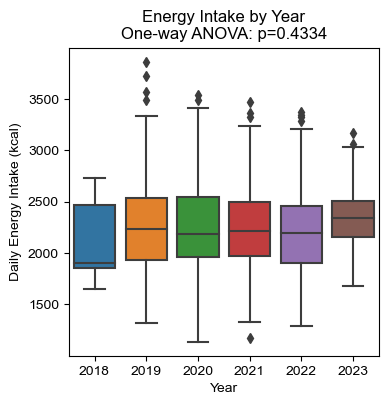

In [23]:
def plot_yearly_energy_with_stats(data, method="anova", show_plot=True):
    """
    Create a boxplot of yearly energy intake with an option to perform either a parametric or non-parametric statistical test.

    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame with columns 'year' and 'energy_kcal_eaten'
    method : str, optional
        "anova" for parametric one-way ANOVA (default) or "kruskal" for Kruskal-Wallis H-test.

    Returns:
    --------
    tuple
        (statistic, p_value) from the selected test.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats

    # Create boxplot

    # Prepare groups for testing
    years = sorted(data["year"].unique())
    groups = [data[data["year"] == year]["energy_kcal_eaten"] for year in years]

    # Perform the selected statistical test
    if method.lower() == "anova":
        statistic, p_val = stats.f_oneway(*groups)
        test_name = "One-way ANOVA"
    elif method.lower() == "kruskal":
        statistic, p_val = stats.kruskal(*groups)
        test_name = "Kruskal-Wallis Test"
    else:
        raise ValueError("Method must be either 'anova' or 'kruskal'.")

    print(f"{test_name} statistic: {statistic:.4f}, p-value: {p_val:.4f}")

    # Add statistical test results to the plot title
    if show_plot:
        plt.figure(figsize=(4, 4))
        sns.boxplot(data=data, y="energy_kcal_eaten", x="year")
        plt.title(f"Energy Intake by Year\n{test_name}: p={p_val:.4f}")
        plt.ylabel("Daily Energy Intake (kcal)")
        plt.xlabel("Year")

    return statistic, p_val


plot_yearly_energy_with_stats(yearly_energy_by_user, method="anova")
plot_yearly_energy_with_stats(yearly_energy_by_user, method="kruskal", show_plot=False)

In [24]:
def test_anova_assumptions(data):
    """
    Test the assumptions for one-way ANOVA:
    1. Normality of residuals using the Shapiro–Wilk test.
    2. Homogeneity of variances using Levene's test.

    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame with columns 'year' and 'energy_kcal_eaten'.

    Returns:
    --------
    dict
        Dictionary containing test statistics and p-values for each assumption.
    """
    import statsmodels.formula.api as smf
    from scipy.stats import shapiro, levene

    # Fit an OLS model to obtain residuals (ANOVA equivalent)
    model = smf.ols("energy_kcal_eaten ~ C(year)", data=data).fit()
    residuals = model.resid

    # 1. Test normality of residuals using Shapiro-Wilk test
    shapiro_stat, shapiro_p = shapiro(residuals)

    # 2. Test homogeneity of variances using Levene's test
    groups = [group["energy_kcal_eaten"].values for _, group in data.groupby("year")]
    levene_stat, levene_p = levene(*groups)

    # Print results
    print("Assumptions test results:")
    print(
        f"Shapiro-Wilk test: statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}"
    )
    print(f"Levene's test: statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")

    return {
        "Shapiro-Wilk": {"statistic": shapiro_stat, "p_value": shapiro_p},
        "Levene": {"statistic": levene_stat, "p_value": levene_p},
    }


test_anova_assumptions(yearly_energy_by_user)

Assumptions test results:
Shapiro-Wilk test: statistic = 0.9888, p-value = 0.0000
Levene's test: statistic = 1.8683, p-value = 0.0972


{'Shapiro-Wilk': {'statistic': 0.988795280456543,
  'p_value': 6.181689400364121e-07},
 'Levene': {'statistic': 1.8683248710834357, 'p_value': 0.09724453430153389}}